# Human Takeover Boundary Analysis

**PS1 Computational Notebook**

**Project:** *When Should Humans Take Over? Recent Errors and Authority under Imperfect Automation*

This notebook implements the computational analysis for the PS1 research proposal.

The study asks whether recent automation error history changes human willingness to take control when the current economic state remains unchanged.

The notebook has four goals:

1. derive the expected-cost takeover benchmark;
2. construct matched Error and No Error scenarios;
3. demonstrate the analysis pipeline with synthetic choices;
4. estimate and compare takeover boundaries across the two history conditions.

The synthetic results are used only as a computational check. They do not establish human behavioral effects.

## 1. Decision model

A human operator supervises an automated system and chooses between:

- **Keep Auto**
- **Take Over**

The current state is defined by:

- \(p\): automation reliability, interpreted as the probability of successful automated operation;
- \(L\): loss if automation fails;
- \(C\): cost of manual takeover.

If automation continues, its expected cost is

\[
EC_{\text{auto}}=(1-p)L.
\]

Manual takeover has cost

\[
EC_{\text{takeover}}=C.
\]

Takeover is expected-cost optimal when

\[
C<(1-p)L.
\]

For \(L>0\), this gives the economic takeover boundary

\[
p^*=1-\frac{C}{L}.
\]

When \(p<p^*\), takeover is preferred. When \(p>p^*\), continued automation is preferred.

## 1. Decision model

A human operator supervises an automated system and chooses between:

- **Keep Auto**
- **Take Over**

The current state is defined by:

- $p$: automation reliability, interpreted as the probability of successful automated operation
- $L$: loss if automation fails
- $C$: cost of manual takeover

If automation continues, its expected cost is

$$
EC_{\text{auto}}=(1-p)L
$$

Manual takeover has cost

$$
EC_{\text{takeover}}=C
$$

Takeover is expected-cost optimal when

$$
C<(1-p)L
$$

For $L>0$, this gives the economic takeover boundary

$$
p^*=1-\frac{C}{L}
$$

When $p<p^*$, takeover is preferred.

When $p>p^*$, continued automation is preferred.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

SEED = 206
rng = np.random.default_rng(SEED)

print("Random seed:", SEED)

Random seed: 206


## 2. Economic benchmark

For the computational demonstration, failure loss and takeover cost are fixed at

$$
L=100
$$

and

$$
C=20
$$

The economic takeover boundary is therefore

$$
p^*=1-\frac{20}{100}=0.80
$$

This means that the expected-cost benchmark recommends takeover when reliability is below 80%, and continued automation when reliability is above 80%.

In [2]:
L = 100
C = 20

p_star = 1 - C / L

print(f"Failure loss L: {L}")
print(f"Takeover cost C: {C}")
print(f"Economic takeover boundary p*: {p_star:.3f}")

Failure loss L: 100
Takeover cost C: 20
Economic takeover boundary p*: 0.800


## 3. Matched scenario design

The behavioral comparison must keep the current economic state unchanged.

Each reliability level is therefore used twice:

- once with **Recent Error**
- once with **No Recent Error**

Within each matched pair, $p$, $L$, and $C$ are identical.

Only recent history changes.

The reliability levels are selected on both sides of the economic boundary, with several values close to $p^*=0.80$.

This is useful because a change in reliance is most likely to alter the final choice when the economic decision is close to the boundary.

In [3]:
reliabilities = np.array([
    0.65,
    0.72,
    0.76,
    0.78,
    0.80,
    0.82,
    0.84,
    0.88,
    0.95
])

scenario_rows = []
scenario_id = 1

for p in reliabilities:
    for history in ["No Error", "Error"]:

        expected_auto_cost = (1 - p) * L

        if C < expected_auto_cost:
            benchmark = "Take Over"
        elif C > expected_auto_cost:
            benchmark = "Keep Auto"
        else:
            benchmark = "Indifferent"

        scenario_rows.append({
            "scenario_id": scenario_id,
            "p": p,
            "L": L,
            "C": C,
            "history": history,
            "expected_auto_cost": expected_auto_cost,
            "benchmark": benchmark
        })

        scenario_id += 1

scenarios = pd.DataFrame(scenario_rows)

scenarios

,scenario_id,p,L,C,history,expected_auto_cost,benchmark
0,1,0.65,100,20,No Error,35.0,Take Over
1,2,0.65,100,20,Error,35.0,Take Over
2,3,0.72,100,20,No Error,28.0,Take Over
3,4,0.72,100,20,Error,28.0,Take Over
4,5,0.76,100,20,No Error,24.0,Take Over
5,6,0.76,100,20,Error,24.0,Take Over
6,7,0.78,100,20,No Error,22.0,Take Over
7,8,0.78,100,20,Error,22.0,Take Over
8,9,0.80,100,20,No Error,20.0,Keep Auto
9,10,0.80,100,20,Error,20.0,Keep Auto


In [4]:
print("Number of reliability levels:", len(reliabilities))
print("Number of scenario conditions:", len(scenarios))
print("Economic boundary:", p_star)

scenarios[
    [
        "scenario_id",
        "p",
        "history",
        "expected_auto_cost",
        "benchmark"
    ]
]

Number of reliability levels: 9
Number of scenario conditions: 18
Economic boundary: 0.8


,scenario_id,p,history,expected_auto_cost,benchmark
0,1,0.65,No Error,35.0,Take Over
1,2,0.65,Error,35.0,Take Over
2,3,0.72,No Error,28.0,Take Over
3,4,0.72,Error,28.0,Take Over
4,5,0.76,No Error,24.0,Take Over
5,6,0.76,Error,24.0,Take Over
6,7,0.78,No Error,22.0,Take Over
7,8,0.78,Error,22.0,Take Over
8,9,0.80,No Error,20.0,Keep Auto
9,10,0.80,Error,20.0,Keep Auto


## 4. Economic boundary visualization

The figure below shows the expected-cost benchmark before any behavioral effect is introduced.

Reliability values below $p^*=0.80$ favor takeover.

Reliability values above $p^*=0.80$ favor continued automation.

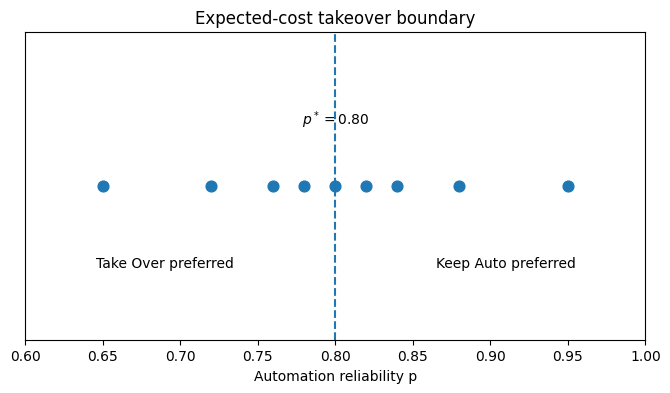

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.axvline(
    p_star,
    linestyle="--"
)

ax.scatter(
    reliabilities,
    np.zeros_like(reliabilities),
    s=60
)

ax.text(
    p_star,
    0.06,
    r"$p^*=0.80$",
    ha="center"
)

ax.text(
    0.69,
    -0.08,
    "Take Over preferred",
    ha="center"
)

ax.text(
    0.91,
    -0.08,
    "Keep Auto preferred",
    ha="center"
)

ax.set_xlim(0.60, 1.00)
ax.set_ylim(-0.15, 0.15)

ax.set_xlabel("Automation reliability p")
ax.set_yticks([])
ax.set_title("Expected-cost takeover boundary")

plt.show()

## 5. Synthetic behavioral check

The next section does **not** use observed human data.

Synthetic choices are generated only to verify that the analysis can detect a takeover-boundary shift if such a pattern exists in future human data.

For the No Error condition, takeover probability is defined as

$$
P(T=1)
=
\sigma\left[\beta(p^*-p)\right]
$$

For the Error condition,

$$
P(T=1)
=
\sigma\left[\beta(p^*-p)+\gamma\right]
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

and $T=1$ denotes takeover.

A positive $\gamma$ creates a synthetic recent-error effect.

The parameters below are chosen only for a transparent computational test. They are not estimated from human participants.

In [6]:
beta = 25.0
gamma = 1.25

synthetic_shift = gamma / beta

print(f"Synthetic slope beta: {beta}")
print(f"Synthetic error effect gamma: {gamma}")
print(f"Implied synthetic boundary shift: {synthetic_shift:.3f}")

Synthetic slope beta: 25.0
Synthetic error effect gamma: 1.25
Implied synthetic boundary shift: 0.050


For this demonstration, 250 synthetic decisions are generated for each reliability and history condition.

The random seed is fixed at 206 so that the synthetic dataset is reproduced exactly on every fresh run.

In [7]:
N_PER_CONDITION = 250

synthetic_rows = []

for history in ["No Error", "Error"]:

    history_indicator = 1 if history == "Error" else 0

    for p in reliabilities:

        logit = (
            beta * (p_star - p)
            + gamma * history_indicator
        )

        takeover_probability = 1 / (1 + np.exp(-logit))

        choices = rng.binomial(
            n=1,
            p=takeover_probability,
            size=N_PER_CONDITION
        )

        for choice in choices:
            synthetic_rows.append({
                "p": p,
                "L": L,
                "C": C,
                "history": history,
                "takeover": choice,
                "synthetic_probability": takeover_probability
            })

synthetic_data = pd.DataFrame(synthetic_rows)

synthetic_data.head()

,p,L,C,history,takeover,synthetic_probability
0,0.65,100,20,No Error,1,0.977023
1,0.65,100,20,No Error,1,0.977023
2,0.65,100,20,No Error,0,0.977023
3,0.65,100,20,No Error,1,0.977023
4,0.65,100,20,No Error,1,0.977023


In [8]:
print("Total synthetic decisions:", len(synthetic_data))

summary = (
    synthetic_data
    .groupby(["history", "p"])
    .agg(
        takeover_rate=("takeover", "mean"),
        n=("takeover", "size")
    )
    .reset_index()
)

summary

Total synthetic decisions: 4500


,history,p,takeover_rate,n
0,Error,0.65,0.996,250
1,Error,0.72,0.936,250
2,Error,0.76,0.904,250
3,Error,0.78,0.856,250
4,Error,0.80,0.736,250
5,Error,0.82,0.676,250
6,Error,0.84,0.568,250
7,Error,0.88,0.308,250
8,Error,0.95,0.076,250
9,No Error,0.65,0.984,250


## 6. Estimating takeover boundaries

For each history condition, a logistic regression is fitted using reliability $p$ to predict the binary takeover choice.

The fitted model has the form

$$
\operatorname{logit}\left[P(T=1)\right]
=
\alpha+\beta_p p
$$

The empirical takeover boundary is defined as the reliability level at which

$$
P(T=1)=0.5
$$

Since

$$
\operatorname{logit}(0.5)=0
$$

the estimated boundary is

$$
\hat{p}
=
-\frac{\alpha}{\beta_p}
$$

The main quantity of interest is

$$
\Delta p
=
\hat{p}_{E}
-
\hat{p}_{N}
$$

where $\hat{p}_{E}$ is the estimated Error boundary and $\hat{p}_{N}$ is the estimated No Error boundary.

A positive $\Delta p$ means that recent error history moves takeover toward higher stated reliability.

In [9]:
boundary_results = []
models = {}

for history in ["No Error", "Error"]:

    subset = synthetic_data[
        synthetic_data["history"] == history
    ]

    X = subset[["p"]]
    y = subset["takeover"]

    model = LogisticRegression(
        C=1e6,
        solver="lbfgs"
    )

    model.fit(X, y)

    intercept = model.intercept_[0]
    coefficient = model.coef_[0][0]

    estimated_boundary = -intercept / coefficient

    models[history] = model

    boundary_results.append({
        "history": history,
        "intercept": intercept,
        "coefficient_p": coefficient,
        "estimated_boundary": estimated_boundary
    })

boundary_table = pd.DataFrame(boundary_results)

boundary_table

,history,intercept,coefficient_p,estimated_boundary
0,No Error,21.024564,-26.261795,0.800576
1,Error,20.483086,-24.145004,0.848336


In [10]:
p_hat_no_error = boundary_table.loc[
    boundary_table["history"] == "No Error",
    "estimated_boundary"
].iloc[0]

p_hat_error = boundary_table.loc[
    boundary_table["history"] == "Error",
    "estimated_boundary"
].iloc[0]

delta_p = p_hat_error - p_hat_no_error

print(f"Economic boundary p*:        {p_star:.3f}")
print(f"No Error boundary:           {p_hat_no_error:.3f}")
print(f"Error boundary:              {p_hat_error:.3f}")
print(f"Boundary shift delta p:      {delta_p:.3f}")

Economic boundary p*:        0.800
No Error boundary:           0.801
Error boundary:              0.848
Boundary shift delta p:      0.048


### Interpretation of the synthetic check

The synthetic analysis recovers a No Error boundary close to the economic benchmark of 0.80.

The Error condition produces a higher estimated takeover boundary.

The resulting positive $\Delta p$ shows that the computational procedure can recover a recent-error boundary shift when such a shift is deliberately built into synthetic choices.

This is **not evidence that real people behave this way**.

A behavioral claim requires actual human choice data collected under the matched experimental design.

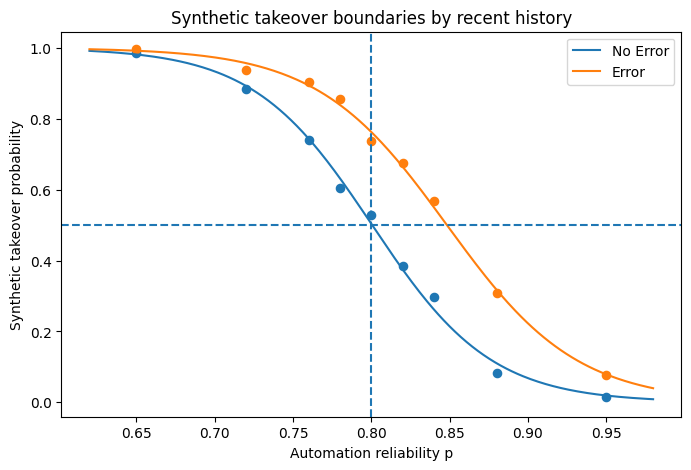

In [11]:
plot_grid = np.linspace(0.62, 0.98, 300)

fig, ax = plt.subplots(figsize=(8, 5))

for history in ["No Error", "Error"]:

    model = models[history]

    probabilities = model.predict_proba(
        pd.DataFrame({"p": plot_grid})
    )[:, 1]

    ax.plot(
        plot_grid,
        probabilities,
        label=history
    )

observed_summary = (
    synthetic_data
    .groupby(["history", "p"])["takeover"]
    .mean()
    .reset_index()
)

for history in ["No Error", "Error"]:

    subset = observed_summary[
        observed_summary["history"] == history
    ]

    ax.scatter(
        subset["p"],
        subset["takeover"],
        s=35
    )

ax.axhline(
    0.5,
    linestyle="--"
)

ax.axvline(
    p_star,
    linestyle="--"
)

ax.set_xlabel("Automation reliability p")
ax.set_ylabel("Synthetic takeover probability")
ax.set_title("Synthetic takeover boundaries by recent history")
ax.legend()

plt.show()

## 7. History effects near the economic boundary

The proposal also considers whether history matters more when the economic choice is close.

Distance from the benchmark is defined as

$$
|p-p^*|
$$

Small values mean that the current reliability lies close to the expected-cost takeover boundary.

Large values mean that one action has a clearer expected-cost advantage.

The following table compares synthetic takeover rates across Error and No Error conditions at each reliability level.

In [12]:
history_comparison = (
    synthetic_data
    .groupby(["p", "history"])["takeover"]
    .mean()
    .unstack()
    .reset_index()
)

history_comparison["error_minus_no_error"] = (
    history_comparison["Error"]
    - history_comparison["No Error"]
)

history_comparison["distance_from_boundary"] = abs(
    history_comparison["p"] - p_star
)

history_comparison = history_comparison[
    [
        "p",
        "distance_from_boundary",
        "No Error",
        "Error",
        "error_minus_no_error"
    ]
]

history_comparison

history,p,distance_from_boundary,No Error,Error,error_minus_no_error
0,0.65,0.15,0.984,0.996,0.012
1,0.72,0.08,0.884,0.936,0.052
2,0.76,0.04,0.740,0.904,0.164
3,0.78,0.02,0.604,0.856,0.252
4,0.80,0.00,0.528,0.736,0.208
5,0.82,0.02,0.384,0.676,0.292
6,0.84,0.04,0.296,0.568,0.272
7,0.88,0.08,0.084,0.308,0.224
8,0.95,0.15,0.016,0.076,0.060


In [13]:
history_comparison.sort_values(
    "distance_from_boundary"
)

history,p,distance_from_boundary,No Error,Error,error_minus_no_error
4,0.80,0.00,0.528,0.736,0.208
5,0.82,0.02,0.384,0.676,0.292
3,0.78,0.02,0.604,0.856,0.252
6,0.84,0.04,0.296,0.568,0.272
2,0.76,0.04,0.740,0.904,0.164
7,0.88,0.08,0.084,0.308,0.224
1,0.72,0.08,0.884,0.936,0.052
8,0.95,0.15,0.016,0.076,0.060
0,0.65,0.15,0.984,0.996,0.012


This comparison is descriptive.

The synthetic model is intentionally constructed with a recent-error effect, so the table does not test a behavioral hypothesis.

Its purpose is to verify that the analysis pipeline can compare history effects at different distances from the economic boundary.

The same procedure can later be applied to actual human choice data.